# HW 1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline

# Загружаем выборку Diamonds

На данной выборке можно проверять работоспособность своего решения

1. PRICE: price in US dollars (326-18,823)
2. CARAT: weight of the diamond (0.2--5.01)
3. CUT: quality of the cut (Fair, Good, Very Good, Premium, Ideal)
4. COLOR: diamond colour, from J (worst) to D (best)
5. CLARITY: a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
6. X: length in mm (0--10.74)
7. Y: width in mm (0--58.9)
8. Z: depth in mm (0--31.8)
9. DEPTH: total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)
10. TABLE: width of top of diamond relative to widest point (43--95)

In [3]:
diamonds_df = pd.read_csv('diamonds.csv')

In [4]:
diamonds_df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


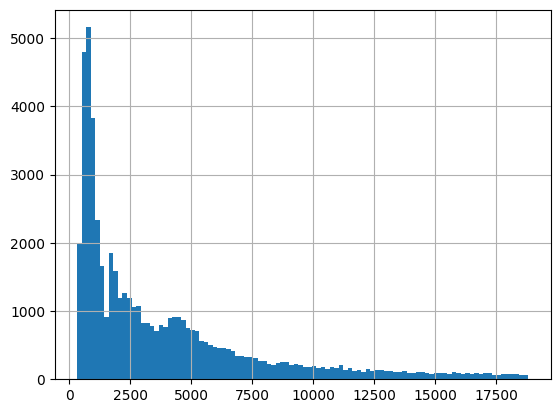

In [5]:
plt.hist(diamonds_df['price'], bins=100)
plt.grid()

# Подготовка данных

In [6]:
features = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
target = ['price']

In [7]:
cut_transform = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
clarity_transform = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}
color_transorm = {'D': 0, 'E': 1, 'F': 2, 'G': 3, 'H': 4, 'I': 5, 'J': 6}

In [8]:
diamonds_df['cut'] = diamonds_df['cut'].apply(lambda x: cut_transform.get(x))
diamonds_df['color'] = diamonds_df['color'].apply(lambda x: color_transorm.get(x))
diamonds_df['clarity'] = diamonds_df['clarity'].apply(lambda x: clarity_transform.get(x))

In [9]:
X = diamonds_df[features].copy().values
y = diamonds_df[target].values

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=47, test_size=0.3)

In [11]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Обучаем модель линейной регрессии

In [107]:
reg = LinearRegression().fit(X_train, y_train)

In [13]:
y_pred = reg.predict(X_test)

In [14]:
score = r2_score(y_pred, y_test)

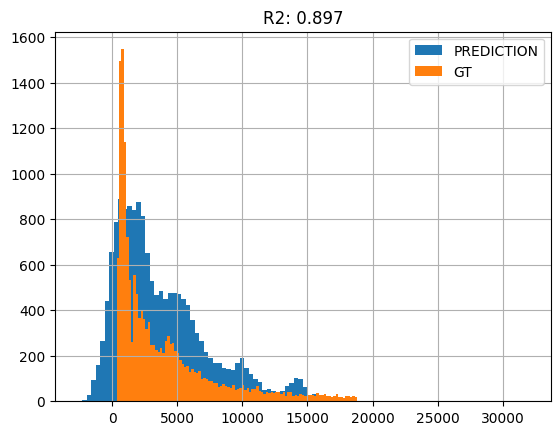

In [15]:
plt.title(f'R2: {str(score)[:5]}')
plt.hist(y_pred.reshape(1, -1)[0], bins=100, label='PREDICTION')
plt.hist(y_test.reshape(1, -1)[0], bins=100, label='GT')
plt.legend()
plt.grid();

# Задание 1: Реализация Gradient Descent для модели линейной регрессии

Ниже представлен шаблон кода, который необходимо дополнить, реализовав все указанные методы, и самостоятельно протестировать корректность решения. Можно (и даже нужно) добавлять свои методы для бОльшей читабельности кода

Достаточно будет, чтобы код работал для случая, когда X и y - np.ndarray

Внутри класса запрещается использовать сторонние библиотеки, кроме numpy

In [18]:
from typing import Optional

In [130]:
class LinearRegressorGD:
    """
    Линейная регрессия с использованием Gradient Descent
    """

    def __init__(self, learning_rate=0.01, n_iter=1000):
        """
        Конструктор класса

        Параметры:
            learning_rate (float): Скорость обучения
            n_iter (int): Количество итераций градиентного спуска
        """
        
        self.penalty: str = 'l2'
        self.alpha: Optional[float] = 0.0001
        self.max_iter: int = n_iter
        self.tol: Optional[float] = 0.0001
        self.random_state: Optional[int] = None
        self.learning_rate = learning_rate
        self.early_stopping: bool = True
        self.validation_fraction: float = 0.1
        self.n_iter_no_change: int = 5
        self.shuffle: bool = False
        self.batch_size: int = 32
        
        if self.random_state is None:
            np.random.seed(self.random_state)
            
    _intercept_: Optional[float]  = None
    _coef_: Optional[np.ndarray] = None
    _best_loss: float = np.inf
    no_improve_count: Optional[int] = None

    
    def calculate_penalty(self, coef: Optional[np.ndarray] = None) -> np.ndarray:
        if coef is None:
            coef = self._coef_
        if self.penalty.upper() == 'L2':
            return 2 * self.alpha * coef
        elif self.penalty.upper() == 'L1':
            return self.alpha * np.sign(coef) 
        
    def calculate_mse(self, X, y):
        y_pred = self.predict(X)
        return np.mean(np.pow((y_pred - y), 2))

    def fit(self, X: np.ndarray, y: np.ndarray):
        """
        Обучение модели на обучающей выборке с использованием
        градиентного спуска

        Параметры:
            X (np.ndarray): Матрица признаков размера (n_samples, n_features)
            y (np.ndarray): Вектор таргета длины n_samples
        """
        if y.shape[1] == 1:
            y = y.ravel()
        n_samples, n_features = X.shape
        self._coef_ = np.random.randn(n_features + 1)
        self._intercept_ = self._coef_[0]
        
        if self.early_stopping:
            split = int((1 - self.validation_fraction) * n_samples)
            X_train, X_test = X[:split], X[split:]
            y_train, y_test = y[:split], y[split:]
        else:
            X_train, y_train = X, y
        
        X_stack = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
        
        for iteration in range(self.max_iter):
            if self.shuffle:
                indices = np.arange(X_train.shape[0])
                np.random.shuffle(indices)
            else:
                indices = np.arange(X_train.shape[0])
            
            for start_idx in range(0, X_train.shape[0], self.batch_size):
                end_idx = start_idx + self.batch_size
                batch_idx = indices[start_idx:end_idx]
                X_batch, y_batch = X_stack[batch_idx], y_train[batch_idx]

                y_pred = np.dot(X_batch, self._coef_)
                error = y_pred - y_batch
                
                grad = 2 / X_batch.shape[0] * np.dot(X_batch.T, error) + self.calculate_penalty(self._coef_)
                
                self._coef_ -= self.learning_rate * grad
            self._intercept_ = self._coef_[0]
            
            if self.early_stopping:
                val_loss = self.calculate_mse(X_test, y_test)
                if val_loss + self.tol < self._best_loss:
                    self._best_loss = val_loss
                    self.no_improve_count = 0
                else:
                    self.no_improve_count += 1
                
                if self.no_improve_count > self.n_iter_no_change:
                    print(f"Early stopping iteration {iteration}")
                    break
        return self

    def predict(self, X):
        """
        Получение предсказаний обученной модели

        Параметры:
            X (np.ndarray): Матрица признаков

        Возвращает:
            np.ndarray: Предсказание для каждого элемента из X
        """
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_bias.dot(self._coef_)


    def get_params(self):
        """
        Возвращает обученные параметры модели
        """
        return {"intercept": self._intercept_, "coef": self._coef_}


In [131]:
my_reg = LinearRegressorGD().fit(X_train, y_train)

In [132]:
y_pred = my_reg.predict(X_test)


In [133]:
score = r2_score(y_pred, y_test)


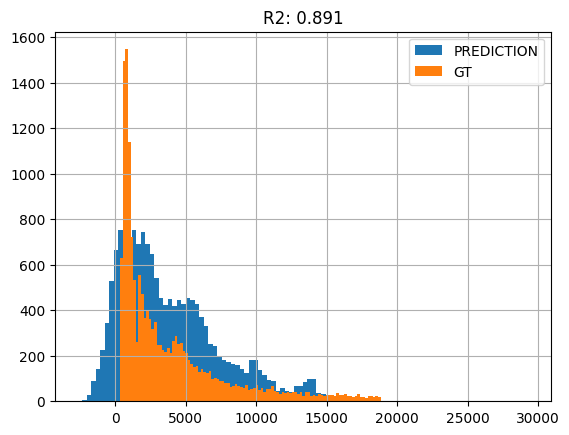

In [134]:
plt.title(f'R2: {str(score)[:5]}')
plt.hist(y_pred.reshape(1, -1)[0], bins=100, label='PREDICTION')
plt.hist(y_test.reshape(1, -1)[0], bins=100, label='GT')
plt.legend()
plt.grid();

# Задание 2: Реализация backpropagation для MLP

Ниже представлен шаблон кода, который необходимо дополнить, реализовав все указанные методы, и самостоятельно протестировать корректность решения. Можно (и даже нужно) добавлять свои методы для бОльшей читабельности кода

Достаточно будет, чтобы код работал для случая, когда X и y - np.ndarray

В качестве функции активации нужно использовать Softmax

Внутри класса запрещается использовать сторонние библиотеки, кроме numpy

In [17]:
class MLPRegressor:
    """
    Многослойный перцептрон (MLP) для задачи регрессии, использующий алгоритм
    обратного распространения ошибки
    """

    def __init__(self, hidden_layer_sizes=(100,), learning_rate=0.01, n_iter=100):
        """
        Конструктор класса

        Параметры:
            hidden_layer_sizes (tuple): Кортеж, определяющий архитектуру
        скрытых слоев. Например (100, 10) - два скрытых слоя, размером 100 и 10
        нейронов, соответственно
            learning_rate (float): Скорость обучения
            n_iter (int): Количество итераций градиентного спуска
        """
        self.hidden_layer_sizes = hidden_layer_sizes
        self.learning_rate = learning_rate

    def forward(self, X):
        """
        Реализация forward pass

        Параметры:
            X (np.ndarray): Матрица признаков размера (n_samples, n_features)

        Возвращает:
            np.ndarray: Предсказания модели
        """
        pass

    def backward(self, X, y):
        """
        Реализация backward pass

        Возвращает:
            X (np.ndarray): Матрица признаков размера (n_samples, n_features)
            y (np.ndarray): Вектор таргета длины n_samples
        """
        pass

    def fit(self, X, y):
        """
        Обучение модели

        Параметры:
            X (np.ndarray): Матрица признаков размера (n_samples, n_features)
            y (np.ndarray): Вектор таргета длины n_samples
        """
        pass

    def predict(self, X):
        """
        Получение предсказаний обученной модели

        Параметры:
            X (np.ndarray): Матрица признаков

        Возвращает:
            np.ndarray: Предсказание для каждого элемента из X
        """
        pass
